# Imports

In [1]:
%cd ..
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, StratifiedKFold, GridSearchCV, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OrdinalEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from Modeling.utils_modeling import (run_gridsearch)

pd.options.display.float_format = '{:.2f}'.format
%cd Modeling

c:\Users\dinis\OneDrive\Ambiente de Trabalho\Faculdade - MGI-BI\1º ano\2º Semestre\Data Mining II\Project\DM2_Project
c:\Users\dinis\OneDrive\Ambiente de Trabalho\Faculdade - MGI-BI\1º ano\2º Semestre\Data Mining II\Project\DM2_Project\Modeling


In [2]:
%cd ..
data = pd.read_csv('Datasets/donors_train.csv')
data.head()
%cd Modelling

c:\Users\dinis\OneDrive\Ambiente de Trabalho\Faculdade - MGI-BI\1º ano\2º Semestre\Data Mining II\Project\DM2_Project
c:\Users\dinis\OneDrive\Ambiente de Trabalho\Faculdade - MGI-BI\1º ano\2º Semestre\Data Mining II\Project\DM2_Project\Modelling


# Other/Extra

In [3]:
cat_cols = list(data.select_dtypes(include='str').columns) + ['INCOME_GROUP',
    'RECENT_STAR_STATUS', 'WEALTH_RATING']
cat_cols

['DONOR_GENDER',
 'HOME_OWNER',
 'RECENCY_STATUS_96NK',
 'SES',
 'URBANICITY',
 'INCOME_GROUP',
 'RECENT_STAR_STATUS',
 'WEALTH_RATING']

## Modeling

In [4]:
def preprocessing(train, val, imputer=None, scaler=None):
    # Outliers

    # Imputation
    if imputer:
        train_imputed = imputer.fit_transform(train)
        val_imputed = imputer.transform(val)
    # Feature Scaling
    if scaler:
        train_scaled = imputer.fit_transform(train)
        val_imputed = imputer.transform(val)
    # Feature Selection
    
    # Feature Encoding

### NaN

In [5]:
pipe = Pipeline([       
    ('scaler', StandardScaler()),   
    ('imputer', KNNImputer()),          
    ('model', DecisionTreeClassifier(random_state=42)) 
])

In [6]:
X = data.drop('TARGET_B', axis=1).select_dtypes('number')
y = data['TARGET_B']

In [7]:
param_grid = [{
        'imputer': [KNNImputer(), None],
        'scaler':  [RobustScaler(), StandardScaler()],
        'model': [DecisionTreeClassifier(), RandomForestClassifier(), KNeighborsClassifier()]
}]

In [8]:
skf_test = StratifiedKFold(n_splits=2, shuffle=True, random_state=23)

In [ ]:
result_df = run_gridsearch(grid=param_grid, cv=skf_test, X=X, y=y, model=pipe)
result_df

Tuning Hyperparameters:   0%|          | 0/12 [00:00<?, ?it/s]

### No NaN

In [ ]:
X_no_nan = data_no_nan.drop('TARGET_B', axis=1).select_dtypes('number')
y_no_nan = data_no_nan['TARGET_B']

In [ ]:
run_gridsearch(grid=param_grid, cv=skf_test, X=X_no_nan, y=y_no_nan, model=pipe)

Tuning Hyperparameters: 100%|██████████| 12/12 [00:04<00:00,  2.67it/s]


,imputer,model,scaler,mean_val_f1,std_val_f1,mean_train_f1,std_train_f1,status
3,KNNImputer(),RandomForestClassifier(),StandardScaler(),0.07,0.01,1.00,0.00,Success
8,None,RandomForestClassifier(),RobustScaler(),0.09,0.01,1.00,0.00,Success
9,None,RandomForestClassifier(),StandardScaler(),0.09,0.03,1.00,0.00,Success
2,KNNImputer(),RandomForestClassifier(),RobustScaler(),0.10,0.03,1.00,0.00,Success
5,KNNImputer(),KNeighborsClassifier(),StandardScaler(),0.20,0.01,0.43,0.01,Success
11,None,KNeighborsClassifier(),StandardScaler(),0.20,0.01,0.43,0.01,Success
10,None,KNeighborsClassifier(),RobustScaler(),0.23,0.01,0.43,0.01,Success
4,KNNImputer(),KNeighborsClassifier(),RobustScaler(),0.23,0.01,0.43,0.01,Success
1,KNNImputer(),DecisionTreeClassifier(),StandardScaler(),0.28,0.02,1.00,0.00,Success
6,None,DecisionTreeClassifier(),RobustScaler(),0.28,0.03,1.00,0.00,Success


## Ignore for now

In [ ]:
k_list = np.arange(1, 20)
scores_train = []
scores_val = []
high_score=0
nof=0
for k in k_list:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train, y_train)
    train_pred = knn_model.predict(X_train)
    val_pred = knn_model.predict(X_val)
    scores_train.append(f1_score(y_train, train_pred))
    scores_val.append(f1_score(y_val, val_pred))
    if(f1_score(y_val, val_pred)>high_score):
        high_score = f1_score(y_val, val_pred)
        nof = k_list[k-1]


print("Best number of neighbors: %d" %nof)
print("Mean F1 score in train with %d neighbors: %f" % (nof, scores_train[nof-1]))
print("Mean F1 score in validation with %d neighbors: %f" % (nof, high_score))

Best number of neighbors: 1
Mean F1 score in train with 1 neighbors: 1.000000
Mean F1 score in validation with 1 neighbors: 0.310606


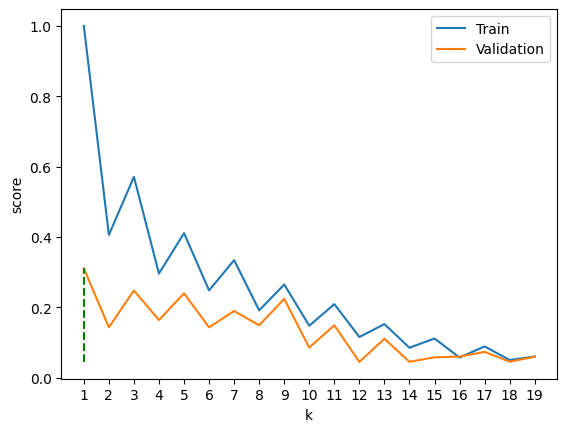

In [ ]:
plt.plot(k_list, scores_train, label='Train')
plt.plot(k_list, scores_val, label = 'Validation')
plt.vlines(x=nof,ymax=high_score,ymin=min(scores_val),ls='--',colors='g')
plt.xticks(k_list)
plt.xlabel('k')
plt.ylabel('score')
plt.legend()

plt.show()